In [1]:
# !pip install tensorflow
# Import with pandas 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Parse dates and set date column to index
df_price_btc = pd.read_csv("data/btc1h_usdt.csv", 
                 parse_dates=["open_time"], 
                 index_col=["open_time"]) # parse the date column (tell pandas column 1 is a datetime)

df_hash_rate = pd.read_csv("data/hash_rate.csv", 
                 parse_dates=["date"], 
                 index_col=["date"]) # parse the date column (tell pandas column 1 is a datetime)



In [2]:
df_price_btc.head();

In [3]:
df_hash_rate.head();

In [4]:
print(df_price_btc.shape)
print(df_hash_rate.shape)
display(df_price_btc.head())
display(df_hash_rate.head())


(64730, 111)
(1506, 2)


,Unnamed: 0,open,high,low,close,volume,close_time,quote_vol,trades,taker_buy_base,...,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,sma200,sma50,ema200,ema50,slope,slope_obv,slope_rsi
open_time,,,,,,,,,,,,,,,,,,,,,
2017-08-17 04:00:00,0,4261.48,4313.62,4261.32,4308.83,47.181009,2017-08-17 04:59:59.999,202366.138393,171.0,35.160503,...,NaN,NaN,NaN,NaN,NaN,4308.830000,4308.830000,NaN,NaN,NaN
2017-08-17 05:00:00,1,4308.83,4328.69,4291.37,4315.32,23.234916,2017-08-17 05:59:59.999,100304.823567,102.0,21.448071,...,NaN,NaN,NaN,NaN,NaN,4308.894577,4309.084510,NaN,NaN,NaN
2017-08-17 06:00:00,2,4330.29,4345.45,4309.37,4324.35,7.229691,2017-08-17 06:59:59.999,31282.312670,36.0,4.802861,...,NaN,NaN,NaN,NaN,NaN,4309.048362,4309.683156,NaN,NaN,NaN
2017-08-17 07:00:00,3,4316.62,4349.99,4287.41,4349.99,4.443249,2017-08-17 07:59:59.999,19241.058300,25.0,2.602292,...,NaN,NaN,NaN,NaN,NaN,4309.455742,4311.263817,NaN,NaN,NaN
2017-08-17 08:00:00,4,4333.32,4377.85,4333.32,4360.69,0.972807,2017-08-17 08:59:59.999,4239.503586,28.0,0.814655,...,NaN,NaN,NaN,NaN,NaN,4309.965536,4313.202099,NaN,NaN,NaN


,timestamp,hash-rate
date,,
2009-01-10,1231545600000,1.065220e-07
2009-01-14,1231891200000,2.521021e-06
2009-01-18,1232236800000,5.588855e-06
2009-01-22,1232582400000,5.681174e-06
2009-01-26,1232928000000,6.270595e-06


In [6]:
# Step 1: Aggregate price data to daily
df_price_daily = df_price_btc.resample('1D').agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
})

# Drop rows with missing essential price data
df_price_daily.dropna(subset=['open', 'high', 'low', 'close'], inplace=True)

# Step 2: Normalize datetime index to ensure alignment
df_price_daily.index = df_price_daily.index.normalize()
df_hash_rate.index = df_hash_rate.index.normalize()

# Step 3: Merge on normalized date index
df_merged = df_price_daily.merge(df_hash_rate, left_index=True, right_index=True, how='inner')

# Step 4: View result
display(df_merged.head())


,open,high,low,close,volume,timestamp,hash-rate
2017-08-20,4120.98,4211.08,4032.62,4086.29,467.083022,1503187200000,6.812005e+06
2017-08-24,4147.00,4371.68,4085.01,4316.01,787.418753,1503532800000,6.372733e+06
2017-08-28,4310.01,4399.82,4124.54,4386.69,603.841616,1503878400000,5.293924e+06
2017-09-01,4689.89,4885.55,4654.88,4834.91,560.666366,1504224000000,6.118104e+06
2017-09-05,4106.97,4484.99,3603.00,4366.47,1228.938157,1504569600000,7.234500e+06


In [7]:
df_merged = df_merged.sort_index()
df_merged = df_merged.sort_index(ascending=True)
print(df_merged.index.min())
print(df_merged.index.max())
display(df_merged.head())
display(df_merged.tail())


2017-08-20 00:00:00
2025-01-06 00:00:00


,open,high,low,close,volume,timestamp,hash-rate
2017-08-20,4120.98,4211.08,4032.62,4086.29,467.083022,1503187200000,6.812005e+06
2017-08-24,4147.00,4371.68,4085.01,4316.01,787.418753,1503532800000,6.372733e+06
2017-08-28,4310.01,4399.82,4124.54,4386.69,603.841616,1503878400000,5.293924e+06
2017-09-01,4689.89,4885.55,4654.88,4834.91,560.666366,1504224000000,6.118104e+06
2017-09-05,4106.97,4484.99,3603.00,4366.47,1228.938157,1504569600000,7.234500e+06


,open,high,low,close,volume,timestamp,hash-rate
2024-12-21,97805.44,99540.61,96398.39,97267.44,23261.76977,1734739200000,7.761135e+08
2024-12-25,98663.58,99569.15,97632.02,99490.99,13977.78092,1735084800000,7.791474e+08
2024-12-29,95300.00,95340.00,93009.52,93749.10,13279.54771,1735430400000,7.776060e+08
2025-01-02,94591.78,97839.50,94392.00,96984.78,21629.60551,1735776000000,7.884684e+08
2025-01-06,98363.61,102480.00,97920.00,102182.85,24608.44887,1736121600000,8.123576e+08


In [8]:
from sklearn.preprocessing import StandardScaler

# Select features for clustering
features = df_merged[['open', 'high', 'low', 'close', 'volume', 'hash-rate']].copy()

# Normalize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


In [9]:
from sklearn.cluster import KMeans

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

# Add cluster labels back to the DataFrame
df_merged['cluster'] = clusters


\\?\C:\Users\vasil\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


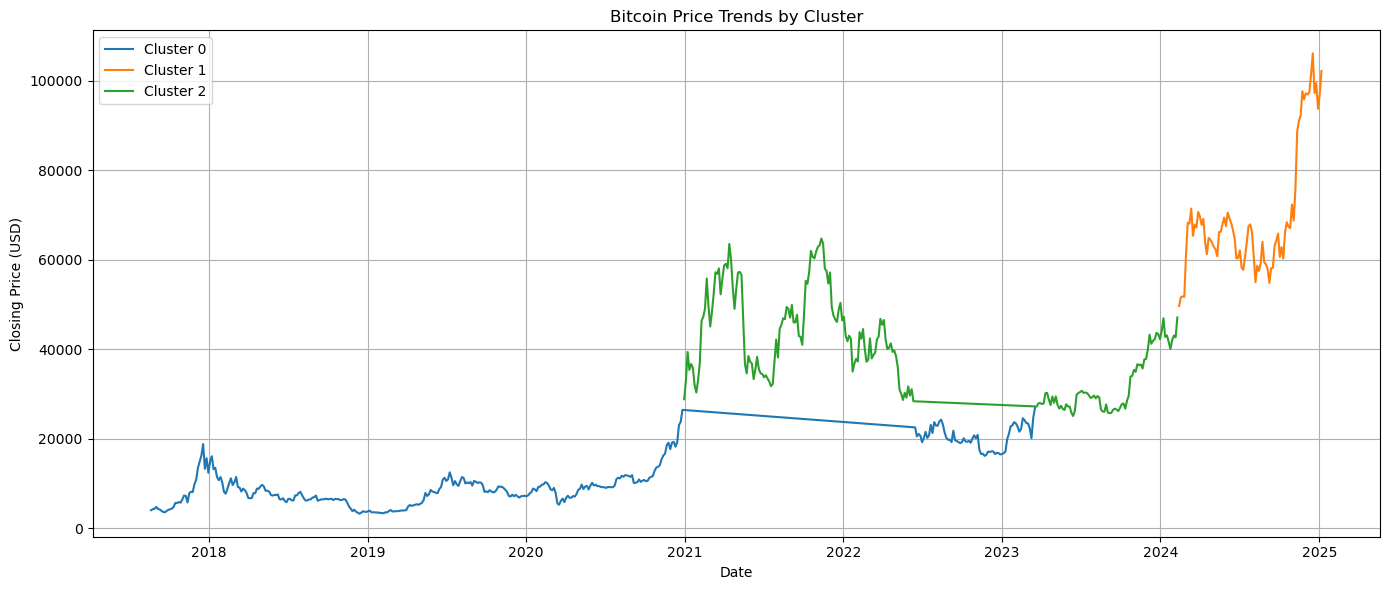

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
for label in sorted(df_merged['cluster'].unique()):
    cluster_data = df_merged[df_merged['cluster'] == label]
    plt.plot(cluster_data.index, cluster_data['close'], label=f'Cluster {label}')

plt.title('Bitcoin Price Trends by Cluster')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
cluster_labels = df_merged['cluster'].tolist()
print(cluster_labels[:10])  # Show first 10 cluster labels as sample


[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [12]:
print(df_merged['cluster'].value_counts().sort_index())


cluster
0    377
1     83
2    215
Name: count, dtype: int64


In [13]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(scaled_features)
df_merged['cluster'] = clusters


\\?\C:\Users\vasil\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [14]:
# Re-check cluster label distribution
print(df_merged['cluster'].value_counts().sort_index())
# Sample output list
print(df_merged['cluster'].tolist()[:10])


cluster
0    314
1     71
2    209
3     66
4     15
Name: count, dtype: int64
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


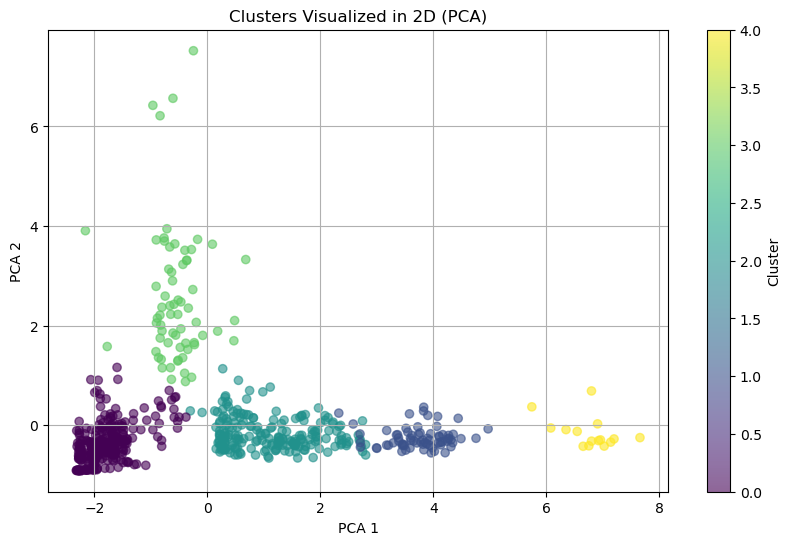

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.title('Clusters Visualized in 2D (PCA)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()
